In [1]:
import networkx as nx
import cvxpy as cp
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from networkx.drawing.nx_pydot import graphviz_layout
from itertools import product
import itertools
from copy import deepcopy

In [2]:
from typing import Any, FrozenSet, Hashable, Iterable, List, Tuple

# IEEE results visualize

In [4]:
data_noise_levels0 = np.load('experiments1_29jun263.npz') #Data was stored in two files because of interruption, combining them here
data_noise_levels1 = np.load('experiments2_29jun261.npz')

In [8]:
opf_costs = np.concatenate((data_noise_levels0['opf'], data_noise_levels1['opf']),axis=0)
vol_costs = np.concatenate((data_noise_levels0['vol'], data_noise_levels1['vol']),axis=0)
bal_costs = np.concatenate((data_noise_levels0['bal'], data_noise_levels1['bal']),axis=0)

In [10]:
noise_levels = np.concatenate((data_noise_levels0['noise'], data_noise_levels1['noise']),axis=0)

In [12]:
opf_costs_coalitions = 1*np.mean(opf_costs,axis=-1)
vol_costs_coalitions = 1*np.mean(vol_costs,axis=-1)
im_costs_coalitions = 1*np.mean(bal_costs,axis=-1)

### Comparing cost breakup for two partitions

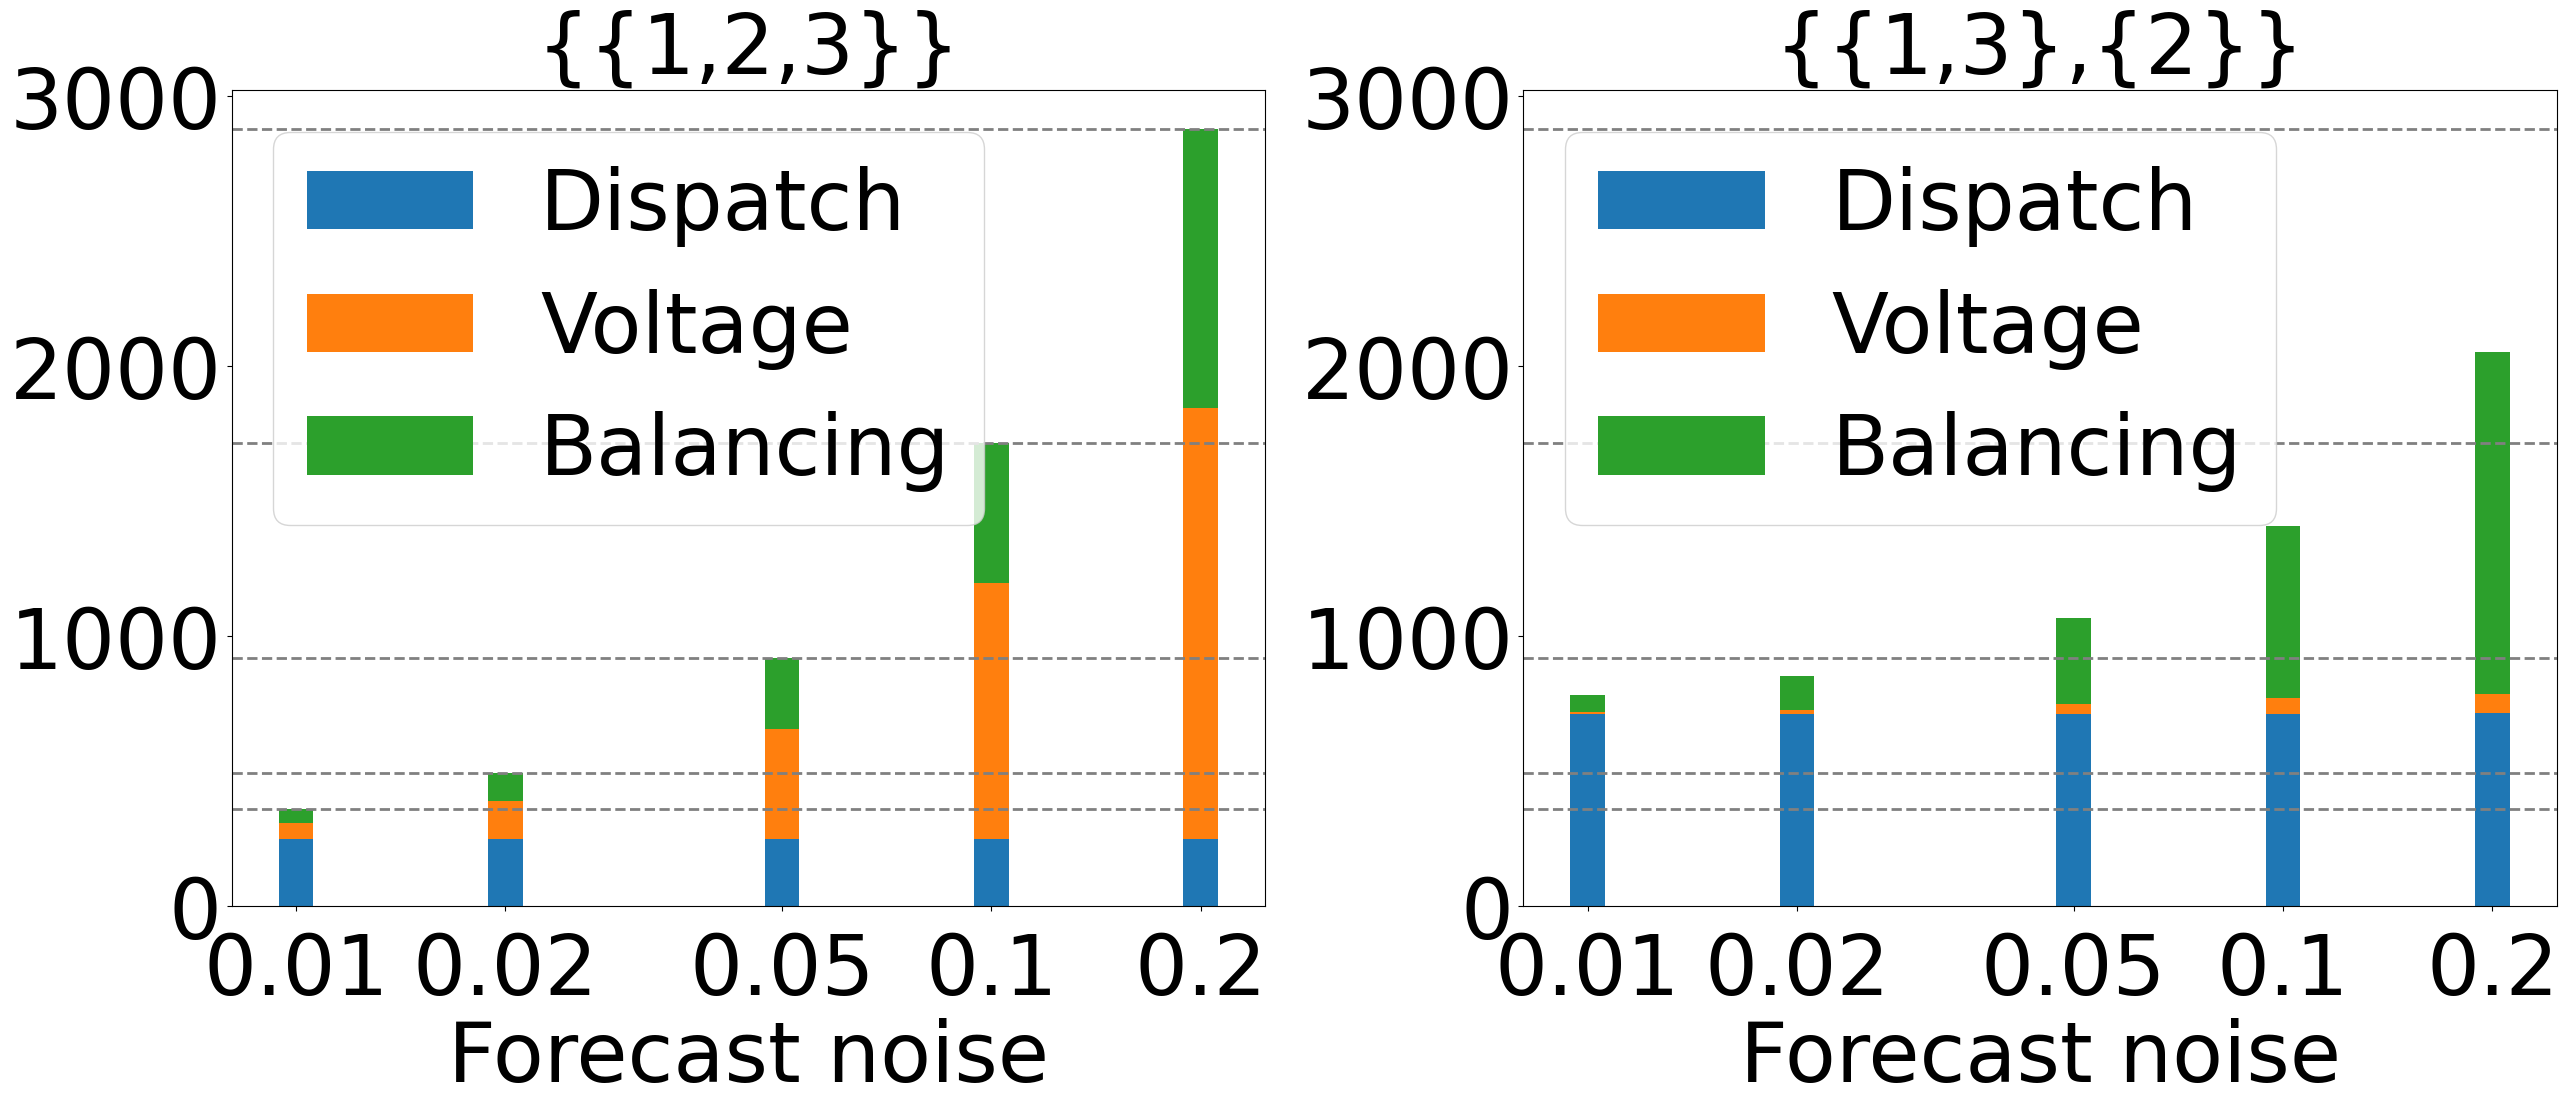

In [15]:
x = np.array([0.01,0.02,0.05,0.1,0.2])
labels = [str(x[i]) for i in range(5)]

fontdict = {'fontsize': 20,
 'fontweight': 1,
 'verticalalignment': 'baseline',
 'horizontalalignment': 'center'}

# Dummy data for the example
# Total cost for first subplot
total1 = (
    opf_costs_coalitions[1:, -1]
    + vol_costs_coalitions[1:, -1]
    + im_costs_coalitions[1:, -1]
)

# Total cost for second subplot
total2 = (
    opf_costs_coalitions[1:, 4] + opf_costs_coalitions[1:, 1]
    + vol_costs_coalitions[1:, 4] + vol_costs_coalitions[1:, 1]
    + im_costs_coalitions[1:, 4] + im_costs_coalitions[1:, 1]
)

# Determine common y-limit
y_max = max(np.max(total1), np.max(total2)) * 1.1  # add 10% headroom

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(30, 12))  # better spacing
ax[0].tick_params(axis='x', pad=20)  # increase spacing below xticks
ax[1].tick_params(axis='x', pad=20)
ax[0].tick_params(axis='y', labelsize=16)
ax[1].tick_params(axis='y', labelsize=16)

w = 0.05
x_log = np.log10(x)

# First subplot
ax[0].bar(x_log, opf_costs_coalitions[1:, -1], width=w, label='Dispatch')
ax[0].bar(
    x_log,
    vol_costs_coalitions[1:, -1],
    width=w,
    bottom=opf_costs_coalitions[1:, -1],
    label='Voltage',
)
ax[0].bar(
    x_log,
    im_costs_coalitions[1:, -1],
    width=w,
    bottom=opf_costs_coalitions[1:, -1] + vol_costs_coalitions[1:, -1],
    label='Balancing',
)

#ax[0].errorbar(x_log, y=total_costs_mean[1:,-1], fmt='None', yerr=total_costs_error[1:,-1], color='black', capsize=10, capthick=5)
ax[0].set_xlabel('Forecast noise',fontsize=60)
#ax[0].set_ylabel('CHF',fontsize=60)
ax[0].set_title('{{1,2,3}}',fontsize=60)
ax[0].set_xticks(x_log)
ax[0].set_xticklabels(labels,fontdict=fontdict)
#ax[0].set_ylim(0, y_max)
#ax[0].set_yticks([0,4000])
#ax[0].set_yticks
ax[0].legend(loc='upper left',fontsize=60)

# Second subplot
ax[1].bar(
    x_log,
    opf_costs_coalitions[1:, 4] + opf_costs_coalitions[1:, 1],
    width=w,
    label='Dispatch',
)
ax[1].bar(
    x_log,
    vol_costs_coalitions[1:, 4] + vol_costs_coalitions[1:, 1],
    width=w,
    bottom=opf_costs_coalitions[1:, 4] + opf_costs_coalitions[1:, 1],
    label='Voltage',
)
ax[1].bar(
    x_log,
    im_costs_coalitions[1:, 4] + im_costs_coalitions[1:, 1],
    width=w,
    bottom=opf_costs_coalitions[1:, 4]
    + opf_costs_coalitions[1:, 1]
    + vol_costs_coalitions[1:, 4]
    + vol_costs_coalitions[1:, 1],
    label='Balancing',
)

# Add dashed horizontal lines from ax[0] bar tops
for xi, total in zip(x_log, total1):
    ax[0].axhline(y=total, color='gray', linestyle='--', linewidth=2)
    ax[1].axhline(y=total, color='gray', linestyle='--', linewidth=2)

#ax[1].errorbar(x_log, y=total_costs_mean[1:,2]+total_costs_mean[1:,3], fmt='None', color='black', yerr=total_costs_error[1:,2]+total_costs_error[1:,3], capsize=10, capthick=5)
ax[1].set_xlabel('Forecast noise',fontsize=60)
#ax[1].set_ylabel('CHF',fontsize=60)
ax[1].set_title('{{1,3},{2}}',fontsize=60)
ax[1].set_xticks(x_log)
#ax[1].set_yticks([0,4000])
ax[1].set_xticklabels(labels,fontdict=fontdict)
#ax[1].set_ylim(0, y_max)
ax[1].legend(loc='upper left',fontsize=60)
ax[0].tick_params(axis='both', labelsize=60)
ax[1].tick_params(axis='both', labelsize=60)
ax[0].tick_params(axis='x', pad=60)   # or 40, depending on spacing
ax[1].tick_params(axis='x', pad=60)
plt.subplots_adjust(wspace=0.25)


#plt.suptitle('Comparison of costs for {1,2,3} vs {{1,2}{3}} for different forecast noise',fontsize=30)
#plt.tight_layout()
plt.subplots_adjust(bottom=0.20)
#plt.subplots_adjust(left=, right=1.05)
# Try 0.15–0.25
plt.savefig('ieee_noisevspartitioncomparison.pdf', format='pdf', bbox_inches='tight')
plt.show()

### Comparing total costs for partitions

In [23]:
class CoalitionLattice:
    def __init__(self, entries: Iterable[Hashable]):
        self.entries: List[Any] = list(entries)
        self.n: int = len(self.entries)
        self._bit = {e: k for k, e in enumerate(self.entries)}
        if len(self._bit) != self.n:
            raise ValueError("entries must be unique and hashable")
 
        # ---- 1. all non-empty coalitions, indexed from 0 ----
        #   list index i  <->  bitmask (i + 1)
        self.coalitions: List[List[Any]] = [
            [self.entries[k] for k in range(self.n) if (mask >> k) & 1]
            for mask in range(1, 1 << self.n)
        ]
 
        # ---- 2. all partitions, indexed from 0 ----
        self.partitions: List[List[List[Any]]] = []
        self.partition_block_indices: List[FrozenSet[int]] = []
        self._partition_index: Dict[FrozenSet[int], int] = {}
 
        for raw in self._iter_set_partitions(list(range(self.n))):
            # each raw block -> bitmask (>= 1) -> 0-based coalition index (mask - 1)
            block_indices = sorted(
                sum(1 << k for k in block) - 1 for block in raw
            )
            partition = [self.coalitions[i] for i in block_indices]
            key = frozenset(block_indices)
            self._partition_index[key] = len(self.partitions)
            self.partition_block_indices.append(key)
            self.partitions.append(partition)
 
    # ---------------- coalitions ----------------
    def coalition(self, index: int) -> List[Any]:
        """Coalition (list of entries) for a given index (0 .. 2**n - 2)."""
        return self.coalitions[index]
 
    def coalition_index(self, coalition: Iterable[Hashable]) -> int:
        """Index for a given coalition (accepts any non-empty iterable of entries)."""
        mask = 0
        for e in coalition:
            mask |= 1 << self._bit[e]
        if mask == 0:
            raise ValueError("the empty coalition has no index")
        return mask - 1
 
    # ---------------- partitions ----------------
    def partition(self, index: int) -> List[List[Any]]:
        """Partition (list of coalitions) for a given index."""
        return self.partitions[index]
 
    def partition_index(self, partition: Iterable[Iterable[Hashable]]) -> int:
        """Index for a given partition (accepts any iterable of blocks)."""
        return self._partition_index[
            frozenset(self.coalition_index(block) for block in partition)
        ]
 
    def coalition_indices(self, partition_index: int) -> FrozenSet[int]:
        """The set of coalition indices that make up a partition."""
        return self.partition_block_indices[partition_index]
 
    def from_coalition_indices(
        self, indices: Iterable[int]
    ) -> Tuple[int, List[List[Any]]]:
        """(partition index, partition) for a given set of coalition indices."""
        j = self._partition_index[frozenset(indices)]
        return j, self.partitions[j]
 
    # ---------------- helpers ----------------
    @property
    def num_coalitions(self) -> int:
        return len(self.coalitions)          # 2**n - 1
 
    @property
    def num_partitions(self) -> int:
        return len(self.partitions)          # Bell number B(n)
 
    @staticmethod
    def _iter_set_partitions(items):
        """Yield every set partition of `items` as a list of blocks."""
        if len(items) <= 1:
            yield [list(items)] if items else []
            return
        first, rest = items[0], items[1:]
        for smaller in CoalitionLattice._iter_set_partitions(rest):
            for i, block in enumerate(smaller):
                yield smaller[:i] + [[first] + block] + smaller[i + 1:]
            yield [[first]] + smaller

In [25]:
total_cost_data_partition1 = np.load('experiments1_total_costs_29jun263.npz',allow_pickle=True)
total_cost_data_partition2 = np.load('experiments2_total_costs_29jun261.npz',allow_pickle=True)

In [27]:
phi_partitions = np.concatenate((total_cost_data_partition1['Phi_partition'],total_cost_data_partition2['Phi_partition']),axis=0)
phi_coalitions = np.concatenate((total_cost_data_partition1['phi_coalition'],total_cost_data_partition2['phi_coalition']),axis=0)

In [29]:
c_l = total_cost_data_partition1['C_L'].item()

## Partition and coalition indexing and retrieval for IEEE

## Stable partitioning: IEEE

In [35]:
noise_idx = 1

stability_flags = np.ones((len(phi_partitions),len(c_l.partitions)))

for noise_idx in range(len(phi_partitions)):
    
    for P_index in range(len(c_l.partitions)):
        P = c_l.partitions[P_index]
        num_C = len(P)
        stable_flag = 1
    
        for C in P:
            #print(C)
            if len(C)==1:
                stable_flag*=1
            else:
                C_index = c_l.coalition_index(C)
                phi_coal = phi_coalitions[noise_idx,C_index, P_index]
    
                c_l_temp = CoalitionLattice(C)
                num_subcoalitions_of_C = c_l_temp.num_coalitions
    
                y = cp.Variable(len(C))
                c = np.zeros(num_subcoalitions_of_C)
                constr = []
                for i in range(num_subcoalitions_of_C):
                    s = c_l_temp.coalition(i)
                    s_idx = c_l.coalition_index(s)
                    #new_partition = (s, coalition minus s, p-coalition)
                    C_temp = C.copy()
                    P_temp = P.copy()
                    for s_ in s:
                        C_temp.remove(s_)
    
                    P_temp.remove(C)
                    
                    new_partition = []
                    new_partition.append(s)
                    if len(C_temp)!=0:
                        new_partition.append(C_temp)
                    if len(P_temp)!=0:
                        for c_p_temp in P_temp:
                            new_partition.append(c_p_temp)
                    
                    new_p_idx = c_l.partition_index(new_partition)
                    
                    cost_s = phi_coalitions[noise_idx, s_idx, new_p_idx]
                    c[i] = cost_s
                    
                    idxs_for_y = np.zeros(len(s),dtype=np.uint8)
                    #print(s)
                    for j in range(len(s)):
                        idxs_for_y[j] = c_l_temp.entries.index(s[j])
                    #print(idxs_for_y)
                    constr.append(cp.sum(y[idxs_for_y])-cost_s<=0)
        
                obj = cp.sum(y)
        
                prob = cp.Problem(cp.Maximize(obj), constr)
                val = prob.solve()
                
                if np.abs(val-phi_coal)<0.1:
                    stable_flag*=1
                else:
                    stable_flag*=0
    
        stability_flags[noise_idx, P_index] = deepcopy(stable_flag)

In [37]:
phi_stable_partitions = np.where(phi_partitions*stability_flags>0, phi_partitions, 1*np.inf*np.ones_like(phi_partitions))

In [39]:
part_idxs_min = np.argmin(phi_stable_partitions,axis=1)

for i in range(len(phi_partitions)):
    print('Noise level = ', noise_levels[i])
    print('Optimal stable partition = ', c_l.partition(part_idxs_min[i]))

Noise level =  0.0
Optimal stable partition =  [['club', 'residential', 'commercial']]
Noise level =  0.01
Optimal stable partition =  [['club', 'residential', 'commercial']]
Noise level =  0.02
Optimal stable partition =  [['club', 'residential', 'commercial']]
Noise level =  0.05
Optimal stable partition =  [['club', 'residential', 'commercial']]
Noise level =  0.1
Optimal stable partition =  [['residential'], ['club', 'commercial']]
Noise level =  0.2
Optimal stable partition =  [['club'], ['residential'], ['commercial']]
